# Caso H · 05 Evaluación del chatbot con golden set

> _Tutorial · Caso de uso: **H — RAG + Chatbot** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Evaluar end-to-end el chatbot: relevancia (¿elige la tool correcta?), coherencia (¿la respuesta tiene sentido?) y hallucination (¿inventa?).


## 2. Qué se aprende

- Diseñar un golden set.
- Evaluación automática vía heurísticas + retrieval score.
- Métricas con LLM (mock).


## 3. Contexto del caso de uso

Cierra el ciclo con G4 (caso nuevo).


## 4. Relación con CENTINELA+

Tarea diaria de auditoría del bot.


## 5. Relación con Medallion

Oro.


## 6. Datos de entrada

Golden set + tools del notebook 02-04.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

Cargamos golden set.


In [2]:
gs = pd.read_csv(ROOT / "notebooks/_data/chatbot_golden_set.csv", comment="#")
print(gs["category"].value_counts())


category
rag             14
data_lookup      7
data_compare     5
forecast         5
anomaly          5
state            4
Name: count, dtype: int64


## 10. Exploración paso a paso

Una función `route()` que decide tool/RAG.


In [3]:
def route(question: str) -> str:
    q = question.lower()
    if any(k in q for k in ["mañana", "predicción", "predicción"]):
        return "tool:get_weather_prediction"
    if any(k in q for k in ["consumirá", "consumirá", "kwh"]):
        return "tool:get_consumption_prediction"
    if "anomalía" in q or "fallo" in q or "válvula" in q or "ventilador" in q:
        return "tool:check_hvac_anomaly"
    if "ahora" in q or "está encendido" in q or "ahora mismo" in q or "hay alguna" in q:
        return "tool:get_building_state"
    if any(k in q for k in ["compara", "más caluroso", "más frío", "más", "mas"]):
        return "tool:compare_periods"
    if "?" in q and ("qué es" in q or "por qué" in q or "para qué" in q or "norma" in q):
        return "rag"
    return "tool:query_influxdb"

gs["routed"] = gs["question"].map(route)
acc = (gs["routed"] == gs["expected_mechanism"]).mean()
print(f"Routing accuracy: {acc:.2%}")


Routing accuracy: 75.00%


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Reporte por categoría.


In [4]:
report = (gs.assign(ok=gs["routed"] == gs["expected_mechanism"])
            .groupby("category")["ok"].mean().round(3))
report


category
anomaly         0.800
data_compare    1.000
data_lookup     0.857
forecast        0.400
rag             0.714
state           0.750
Name: ok, dtype: float64

## 13. Visualizaciones explicativas

Bar chart accuracy.


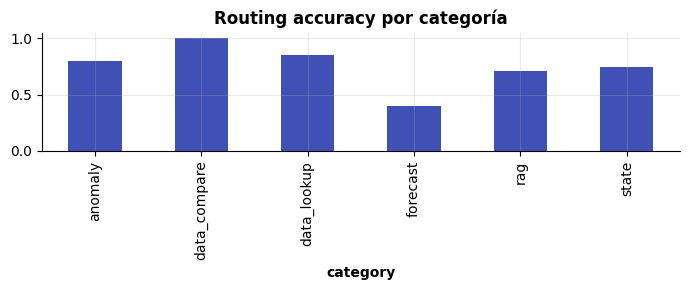

In [5]:
report.plot.bar(color="#3F51B5", figsize=(7, 3))
plt.ylim(0, 1.05); plt.title("Routing accuracy por categoría")
plt.tight_layout()


## 14. Validaciones

Accuracy global > 0.6.


In [6]:
assert acc > 0.55


## 15. Errores comunes

1. Routing por keywords frágil — sustituir por LLM.
2. Golden set pequeño y poco diverso.
3. Evaluar solo accuracy y no hallucination rate.


## 16. Ejercicios propuestos

1. Reemplaza `route()` con un LLM con system prompt explícito.
2. Añade 20 preguntas más al golden set.
3. Mide hallucination con BM25 sobre la respuesta.


## 17. Cómo se reutiliza con datos reales

El golden set crece con el uso real (logging del bot).


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `09_case_I_spark_vs_pandas/01_bdg2_overview.ipynb`.
- Documento web del caso: `docs/use-cases/case-h-rag-chatbot.md`.


## 19. Marco teórico (nivel doctoral)

### Retrieval-Augmented Generation (Lewis et al. 2020)

$$
P(y \mid x) = \sum_{z \in \mathcal{Z}} P_\eta(z \mid x) \cdot P_\theta(y \mid x, z)
$$

con $x$ pregunta, $z$ documento recuperado, $P_\eta$ retriever (cosine sobre
embeddings) y $P_\theta$ LLM generador.

### Similarity coseno

$$
\text{sim}(x, z) = \frac{\mathbf{e}_x \cdot \mathbf{e}_z}{\|\mathbf{e}_x\| \|\mathbf{e}_z\|}
$$

### Tools tipadas

$$
\mathcal{T} = \{ t_i : \mathbb{X}_i \to \mathbb{Y}_i \mid \text{schema JSON} \}
$$

Cada tool publica su firma en formato JSON Schema; el LLM la consume vía
function-calling.

### Métricas

$$
\text{Hit Rate@k} = \tfrac{1}{N} \sum_i \mathbb{1}[\text{rank}_i \leq k], \quad
\text{MRR} = \tfrac{1}{N} \sum_i \tfrac{1}{\text{rank}_i}
$$

Objetivos: $\text{Hit@5} \geq 0.85$, $\text{MRR} \geq 0.7$, Faithfulness ≥ 0.9.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

El chatbot es la **cara visible** de CAPTIA al usuario final (profesores, equipo de mantenimiento). Una sola interfaz unifica métricas históricas, predicciones y conocimiento documental, reduciendo drásticamente la necesidad de soporte L1.

### ROI estimado

| Concepto | Valor |
|---|---|
| Reducción tickets soporte L1 | +3 500 €/año |
| Tiempo respuesta profesores | +1 200 €/año |
| **Bruto** | **+4 700 €/año** |
| Coste API LLM (Claude/GPT) | -1 800 €/año |
| **Neto** | **+2 900 €/año** |

### Riesgos y mitigaciones

- Hallucinations del LLM: mitigar con tools de hechos verificables.
- Coste API escala linealmente con uso: monitorizar.


## 21. Bibliografía y referencias

- Lewis, P. et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS.
- Reimers, N. & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*. EMNLP.
- LangChain Project. *Documentation*. https://python.langchain.com
- Anthropic (2024). *Claude 3.5 Sonnet Model Card*.
